In [1]:
!pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128
!pip install yfinance torch scikit-learn matplotlib pandas numpy
!pip install pandas_market_calendars

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install torch and torchvision==0.27.0.dev20260407+cu128 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested torch
    torchvision 0.27.0.dev20260407+cu128 depends on torch==2.12.0.dev20260407

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [2]:
import math
import torch
import numpy as np
import pandas as pd
import yfinance as yf
import torch.nn as nn
from datetime import datetime
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [3]:
print("GPU disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Modelo da GPU:", torch.cuda.get_device_name(0))

GPU disponível: True
Modelo da GPU: NVIDIA GeForce RTX 5080


In [4]:
ticker="PETR4.SA"

In [5]:
def model_evaluation(message:str,scaler,model_predictions:torch.Tensor,y)->None:
    predictions = scaler.inverse_transform(model_predictions)
    real_values = scaler.inverse_transform(y)
    
    mae = mean_absolute_error(real_values, predictions)
    mape = mean_absolute_percentage_error(real_values, predictions) * 100
    rmse = np.sqrt(np.mean((real_values - predictions) ** 2))
    
    print(message)
    print("-" * 50)
    print(f"MAE  (Erro Médio Absoluto)    : R$ {mae:.2f}")
    print(f"MAPE (Erro Percentual Médio)  : {mape:.2f}%")
    print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:.2f}")
    print("-" * 50)
    
def get_data(start_date:str,end_date:str,ticker:str="PETR4.SA"):
    return yf.download(ticker, start=start_date, end=end_date)
    
def generate_sequences(data, time_window=60):
    X = []
    y = []
    for i in range(len(data) - time_window):
        X.append(data[i : i + time_window])
        y.append(data[i + time_window])
    return np.array(X), np.array(y)

def generate_multi_sequences(X_data, y_data, time_window=60):
    X, y = [], []
    for i in range(len(X_data) - time_window):
        X.append(X_data[i : i + time_window])
        y.append(y_data[i + time_window])
    return np.array(X), np.array(y)

def split_data_in_tensors(X,y,seed=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=False)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    print(f"Treino - X: {X_train_tensor.shape}, y: {y_train_tensor.shape}")
    print(f"Teste  - X: {X_test_tensor.shape}, y: {y_test_tensor.shape}")
    return X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test


def train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,epochs):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions= model(X_train_tensor)
        loss = criterion(predictions, y_train_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] -> Erro (Loss): {loss.item():.6f}")
    

In [6]:
class SharesPredictionModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(SharesPredictionModel, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        
        out = self.fc(out[:, -1, :])
        return out

In [7]:
data=get_data("2021-01-01","2026-03-27")
prices = data['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
normalized_prices = scaler.fit_transform(prices)

WINDOW = 60
X, y = generate_sequences(normalized_prices, WINDOW)

print(f"Formato de X (Amostras, Dias, Features): {X.shape}")
print(f"Formato de y (Amostras, Alvo): {y.shape}")

[*********************100%***********************]  1 of 1 completed

Formato de X (Amostras, Dias, Features): (1244, 60, 1)
Formato de y (Amostras, Alvo): (1244, 1)


In [8]:
X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test=split_data_in_tensors(X,y)
model = SharesPredictionModel()
EPOCHS = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Iniciando o treinamento...")
train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,EPOCHS)
print("Treinamento concluído!")


Treino - X: torch.Size([995, 60, 1]), y: torch.Size([995, 1])
Teste  - X: torch.Size([249, 60, 1]), y: torch.Size([249, 1])
Iniciando o treinamento...
Época [10/100] -> Erro (Loss): 0.049076
Época [20/100] -> Erro (Loss): 0.041829
Época [30/100] -> Erro (Loss): 0.032309
Época [40/100] -> Erro (Loss): 0.016084
Época [50/100] -> Erro (Loss): 0.005392
Época [60/100] -> Erro (Loss): 0.002541
Época [70/100] -> Erro (Loss): 0.001517
Época [80/100] -> Erro (Loss): 0.000918
Época [90/100] -> Erro (Loss): 0.000604
Época [100/100] -> Erro (Loss): 0.000474
Treinamento concluído!


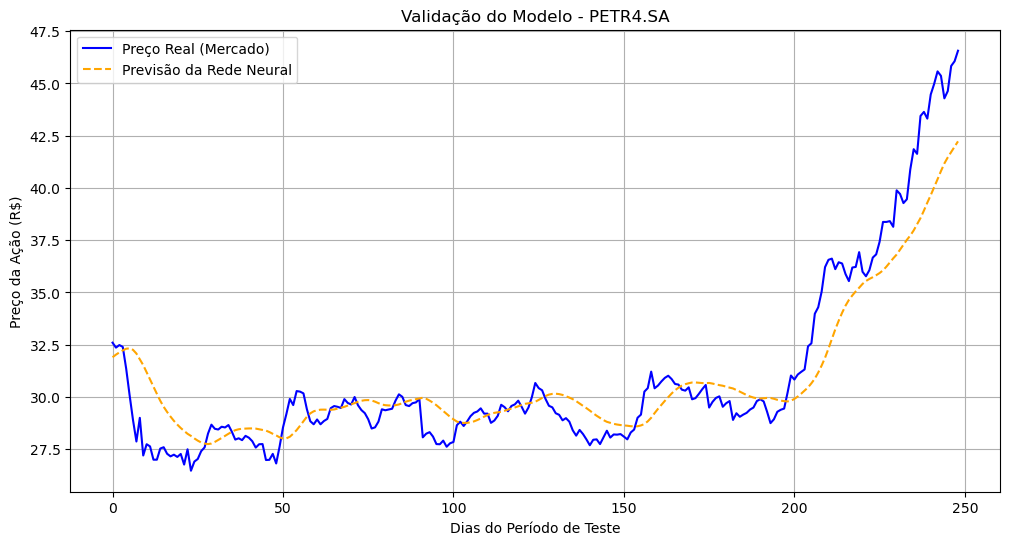

--------------------------------------------------
 PREVISÃO PARA O PRÓXIMO DIA ÚTIL:
Preço previsto pela LSTM para PETR4.SA: R$ 42.49


[*********************100%***********************]  1 of 1 completed

Preço real dia seguinte: R$ 41.81
--------------------------------------------------
 RELATÓRIO DE AVALIAÇÃO DA REDE NEURAL
--------------------------------------------------
MAE  (Erro Médio Absoluto)    : R$ 1.21
MAPE (Erro Percentual Médio)  : 3.71%
RMSE (Raiz do Erro Quadrático): R$ 1.68
--------------------------------------------------


In [9]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    
unnormalized_predictions = scaler.inverse_transform(predictions)
real_values = scaler.inverse_transform(y_test)

plt.figure(figsize=(12, 6))
plt.plot(real_values, label="Preço Real (Mercado)", color="blue")
plt.plot(unnormalized_predictions, label="Previsão da Rede Neural", color="orange", linestyle="--")
plt.title(f"Validação do Modelo - {ticker}")
plt.xlabel("Dias do Período de Teste")
plt.ylabel("Preço da Ação (R$)")
plt.legend()
plt.grid(True)
plt.show()

last_60_days = normalized_prices[-60:]

tomorrow_entrance = torch.tensor(last_60_days, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    prediction = model(tomorrow_entrance).numpy()

unnormalized_prediction = scaler.inverse_transform(prediction)

print("-" * 50)
print(f" PREVISÃO PARA O PRÓXIMO DIA ÚTIL:")
print(f"Preço previsto pela LSTM para {ticker}: R$ {unnormalized_prediction[0][0]:.2f}")
print(f"Preço real dia seguinte: R$ {float(get_data('2026-05-28','2026-05-29')['Close'].values.item()):.2f}")
print("-" * 50)
message=" RELATÓRIO DE AVALIAÇÃO DA REDE NEURAL"
model_evaluation(message,scaler ,predictions,y_test_tensor)

# Aplicando melhoras

Usando 3 colunas, e treinando por mais epocas

In [10]:
data=get_data("2021-01-01","2026-05-27")

data['MA20'] = data['Close'].rolling(window=20).mean()

data = data.dropna()

entrance_columns = ['Close', 'Volume', 'MA20']
data_X = data[entrance_columns].values
data_y = data['Close'].values.reshape(-1, 1)

print(f"Formato dos dados de entrada (X): {data_X.shape}")
print(f"Formato do alvo (y): {data_y.shape}")

[*********************100%***********************]  1 of 1 completed

Formato dos dados de entrada (X): (1325, 3)
Formato do alvo (y): (1325, 1)


In [11]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

normalized_X_data = scaler_X.fit_transform(data_X)
normalized_Y_data = scaler_y.fit_transform(data_y)


WINDOW = 60
X, y = generate_multi_sequences(normalized_X_data, normalized_Y_data, WINDOW)

print(f"Novo formato de X para o PyTorch: {X.shape}") 

Novo formato de X para o PyTorch: (1265, 60, 3)


In [12]:
class ModeloPrevisaoAcoesMulti(nn.Module):
    def __init__(self, input_size=3, hidden_size=50, num_layers=2):
        super(ModeloPrevisaoAcoesMulti, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model= ModeloPrevisaoAcoesMulti()
print(model)

ModeloPrevisaoAcoesMulti(
  (lstm): LSTM(3, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [13]:
X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test=split_data_in_tensors(X,y)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 300

print("Iniciando o treinamento do modelo Multi-Feature...")
train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,EPOCHS)

print("Treinamento concluído!")

Treino - X: torch.Size([1012, 60, 3]), y: torch.Size([1012, 1])
Teste  - X: torch.Size([253, 60, 3]), y: torch.Size([253, 1])
Iniciando o treinamento do modelo Multi-Feature...
Época [10/300] -> Erro (Loss): 0.059590
Época [20/300] -> Erro (Loss): 0.040494
Época [30/300] -> Erro (Loss): 0.031505
Época [40/300] -> Erro (Loss): 0.021091
Época [50/300] -> Erro (Loss): 0.006489
Época [60/300] -> Erro (Loss): 0.003577
Época [70/300] -> Erro (Loss): 0.001829
Época [80/300] -> Erro (Loss): 0.001602
Época [90/300] -> Erro (Loss): 0.001209
Época [100/300] -> Erro (Loss): 0.001059
Época [110/300] -> Erro (Loss): 0.000910
Época [120/300] -> Erro (Loss): 0.000803
Época [130/300] -> Erro (Loss): 0.000721
Época [140/300] -> Erro (Loss): 0.000659
Época [150/300] -> Erro (Loss): 0.000614
Época [160/300] -> Erro (Loss): 0.000584
Época [170/300] -> Erro (Loss): 0.000566
Época [180/300] -> Erro (Loss): 0.000554
Época [190/300] -> Erro (Loss): 0.000547
Época [200/300] -> Erro (Loss): 0.000542
Época [210/3

In [14]:
model.eval()
with torch.no_grad():
    predictions= model(X_test_tensor).numpy()

unnormalized_predictions = scaler_y.inverse_transform(predictions)

message="NOVO RELATÓRIO DE AVALIAÇÃO (COM 3 COLUNAS)"
model_evaluation(message,scaler_y,predictions,y_test)
print(f"Preço previsto pela LSTM para {ticker}: R$ {unnormalized_prediction[0][0]:.2f}")
print(f"Preço real dia seguinte: R$ {float(get_data('2026-05-28','2026-05-29')['Close'].values.item()):.2f}")

[*********************100%***********************]  1 of 1 completed

NOVO RELATÓRIO DE AVALIAÇÃO (COM 3 COLUNAS)
--------------------------------------------------
MAE  (Erro Médio Absoluto)    : R$ 2.34
MAPE (Erro Percentual Médio)  : 5.91%
RMSE (Raiz do Erro Quadrático): R$ 3.51
--------------------------------------------------
Preço previsto pela LSTM para PETR4.SA: R$ 42.49
Preço real dia seguinte: R$ 41.81


# MAIS aprimoramentos, dropout, mais variaveis e retorno percentual 

In [15]:
data =get_data("2021-01-01","2026-05-29")

data['Retorno'] = data['Close'].pct_change()
data['MM20'] = data['Close'].rolling(window=20).mean()
data= data.dropna()


X_columns = ['Retorno', 'Volume', 'MM20']
X_data = data[X_columns].values
y_data = data['Close'].values.reshape(-1, 1)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
normalized_X_data = scaler_X.fit_transform(X_data)
normalized_y_data = scaler_y.fit_transform(y_data)


WINDOW = 60
X, y = generate_multi_sequences(normalized_X_data, normalized_y_data, WINDOW)
X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test=split_data_in_tensors(X,y)

[*********************100%***********************]  1 of 1 completed

Treino - X: torch.Size([1013, 60, 3]), y: torch.Size([1013, 1])
Teste  - X: torch.Size([254, 60, 3]), y: torch.Size([254, 1])


In [16]:
class LeanGRUModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=50, num_layers=2):
        super(LeanGRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

model = LeanGRUModel()

In [17]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 300
print("Iniciando o treinamento do modelo GRU...")
train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,EPOCHS)

print("Treinamento concluído!")



Iniciando o treinamento do modelo GRU...
Época [10/300] -> Erro (Loss): 0.035359
Época [20/300] -> Erro (Loss): 0.028170
Época [30/300] -> Erro (Loss): 0.020188
Época [40/300] -> Erro (Loss): 0.007059
Época [50/300] -> Erro (Loss): 0.002181
Época [60/300] -> Erro (Loss): 0.000944
Época [70/300] -> Erro (Loss): 0.001196
Época [80/300] -> Erro (Loss): 0.000858
Época [90/300] -> Erro (Loss): 0.000861
Época [100/300] -> Erro (Loss): 0.000826
Época [110/300] -> Erro (Loss): 0.000875
Época [120/300] -> Erro (Loss): 0.000763
Época [130/300] -> Erro (Loss): 0.000820
Época [140/300] -> Erro (Loss): 0.000793
Época [150/300] -> Erro (Loss): 0.000780
Época [160/300] -> Erro (Loss): 0.000759
Época [170/300] -> Erro (Loss): 0.000731
Época [180/300] -> Erro (Loss): 0.000719
Época [190/300] -> Erro (Loss): 0.000708
Época [200/300] -> Erro (Loss): 0.000740
Época [210/300] -> Erro (Loss): 0.000670
Época [220/300] -> Erro (Loss): 0.000704
Época [230/300] -> Erro (Loss): 0.000687
Época [240/300] -> Erro (

In [18]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
unnormalized_predictions = scaler_y.inverse_transform(predictions)
real_values = scaler_y.inverse_transform(y_test)
message="RELATÓRIO DO MODELO GRU"
model_evaluation(message,scaler_y,predictions,y_test)


RELATÓRIO DO MODELO GRU
--------------------------------------------------
MAE  (Erro Médio Absoluto)    : R$ 2.02
MAPE (Erro Percentual Médio)  : 5.25%
RMSE (Raiz do Erro Quadrático): R$ 2.97
--------------------------------------------------


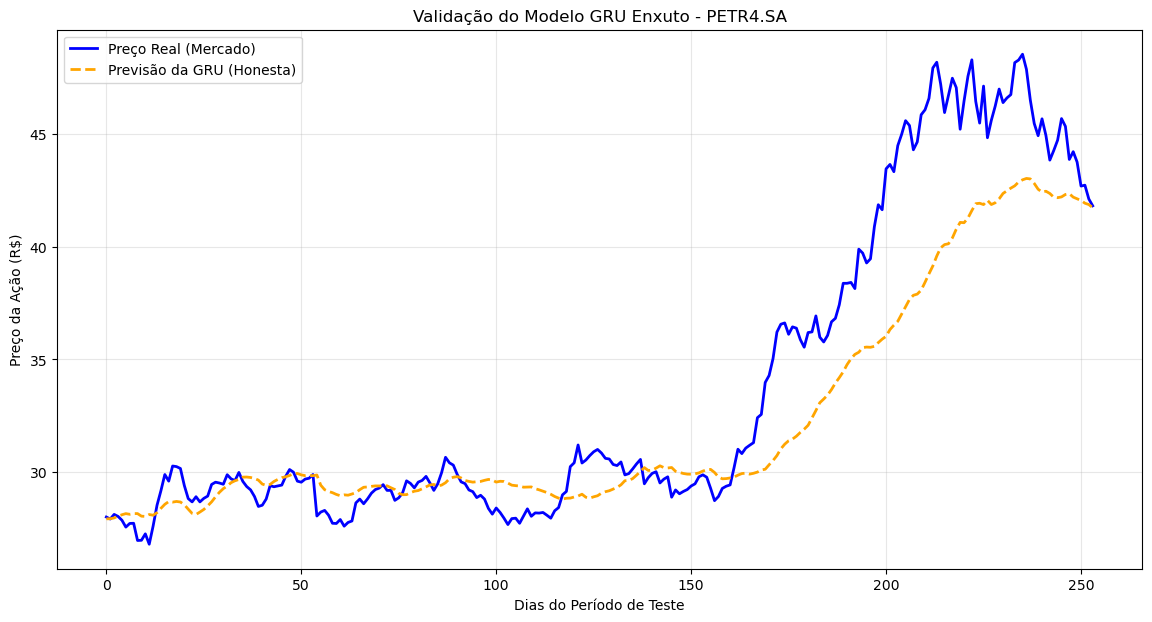

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(real_values, label="Preço Real (Mercado)", color="blue", linewidth=2)
plt.plot(unnormalized_predictions, label="Previsão da GRU (Honesta)", color="orange", linestyle="--", linewidth=2)

plt.title(f"Validação do Modelo GRU Enxuto - {ticker}")
plt.xlabel("Dias do Período de Teste")
plt.ylabel("Preço da Ação (R$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tranformers

In [20]:

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x
        
class TransformerModel(nn.Module):
    def __init__(self, input_size=3, d_model=32, nhead=4, num_layers=2, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.d_model = d_model
        
        self.linear_entrance = nn.Linear(input_size, d_model)
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead,
            dropout=dropout, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.linear_entrance(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
    
        x = self.transformer_encoder(x)
        
        out = self.fc(x[:, -1, :])
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Rodando o treinamento na: {device.type.upper()}") 

model = TransformerModel().to(device)

print(model)

🚀 Rodando o treinamento na: CUDA
TransformerModel(
  (linear_entrance): Linear(in_features=3, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [21]:
data =get_data("2021-01-01","2026-05-29")

data['Retorno'] = data['Close'].pct_change()
data['MM20'] = data['Close'].rolling(window=20).mean()
data= data.dropna()

X_columns = ['Retorno', 'Volume', 'MM20']
X_data = data[X_columns].values
y_data = data['Close'].values.reshape(-1, 1)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
normalized_X_data = scaler_X.fit_transform(X_data)
normalized_y_data = scaler_y.fit_transform(y_data)
WINDOW = 60
X, y = generate_multi_sequences(normalized_X_data, normalized_y_data, WINDOW)
X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test=split_data_in_tensors(X,y)
criterion = nn.MSELoss()
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 300
print("Iniciando o treinamento do Transformer...")

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    
    X_train_gpu = X_train_tensor.to(device)
    y_train_gpu = y_train_tensor.to(device)
    
    predictions = model(X_train_gpu)
    loss = criterion(predictions, y_train_gpu)
    
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 30 == 0:
        print(f"Época [{epoch+1}/{EPOCHS}] -> Loss: {loss.item():.6f}")

print("Treinamento do Transformer Concluído!")

[*********************100%***********************]  1 of 1 completed

Treino - X: torch.Size([1013, 60, 3]), y: torch.Size([1013, 1])
Teste  - X: torch.Size([254, 60, 3]), y: torch.Size([254, 1])
Iniciando o treinamento do Transformer...


Época [30/300] -> Loss: 0.041283
Época [60/300] -> Loss: 0.008972
Época [90/300] -> Loss: 0.005994
Época [120/300] -> Loss: 0.004352
Época [150/300] -> Loss: 0.003143
Época [180/300] -> Loss: 0.002563
Época [210/300] -> Loss: 0.002169
Época [240/300] -> Loss: 0.001757
Época [270/300] -> Loss: 0.001655
Época [300/300] -> Loss: 0.001513
Treinamento do Transformer Concluído!


In [22]:
model.eval()
with torch.no_grad():
    X_test_gpu = X_test_tensor.to(device)
    predictions = model(X_test_gpu).cpu().numpy()
unnormalized_predictions = scaler_y.inverse_transform(predictions)
real_values = scaler_y.inverse_transform(y_test)
message="RELATÓRIO DO MODELO TRANSFORMER (AUTO-ATENÇÃO)"
model_evaluation(message,scaler_y,predictions,y_test)

RELATÓRIO DO MODELO TRANSFORMER (AUTO-ATENÇÃO)
--------------------------------------------------
MAE  (Erro Médio Absoluto)    : R$ 4.03
MAPE (Erro Percentual Médio)  : 10.35%
RMSE (Raiz do Erro Quadrático): R$ 5.79
--------------------------------------------------


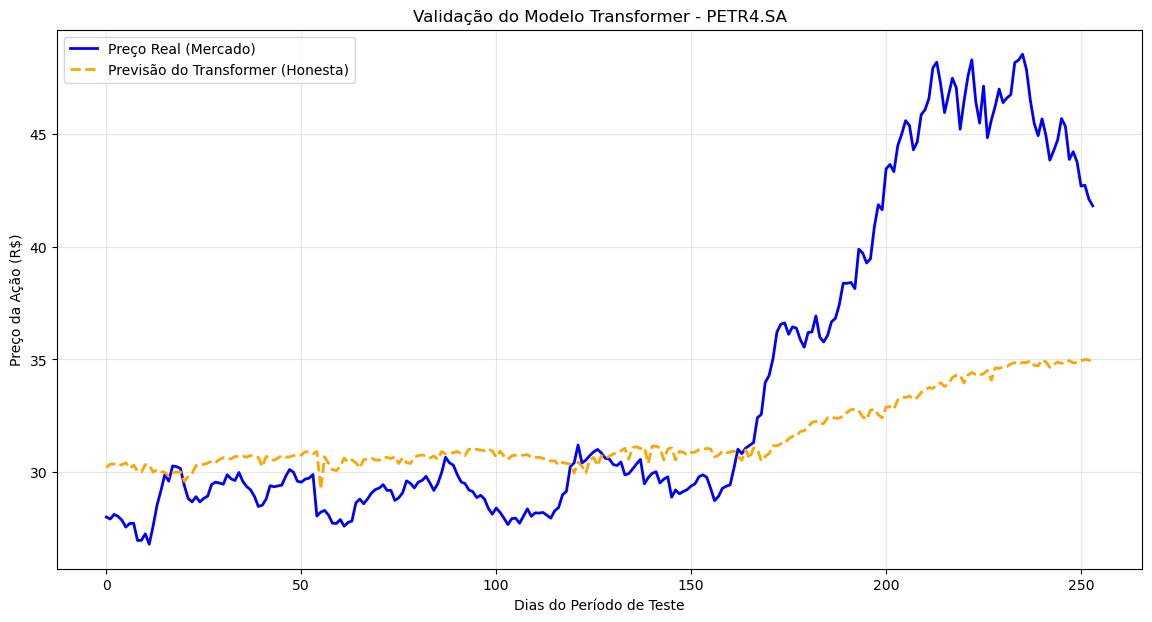

In [23]:
plt.figure(figsize=(14, 7))
plt.plot(real_values, label="Preço Real (Mercado)", color="blue", linewidth=2)
plt.plot(unnormalized_predictions, label="Previsão do Transformer (Honesta)", color="orange", linestyle="--", linewidth=2)

plt.title(f"Validação do Modelo Transformer - {ticker}")
plt.xlabel("Dias do Período de Teste")
plt.ylabel("Preço da Ação (R$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()